# Modelo de Predicción Lineal — 5000 Datos

Análisis completo con características estadísticas principales

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy import stats
%matplotlib inline

## 1. Generación de 5,000 datos lineales

In [3]:
np.random.seed(7)
unidades = np.random.randint(1, 10000, 5000)
ruido    = np.random.normal(0, 25000, 5000)
importe  = 250 * unidades + 50000 + ruido
importe  = np.clip(importe, 1000, None)

df = pd.DataFrame({'Unidades': unidades, 'Importe': importe})
print(f'Datos generados: {len(df)} filas')
df.describe().round(2)

Datos generados: 5000 filas


,Unidades,Importe
count,5000.00,5000.00
mean,4955.24,1289008.82
std,2886.86,721701.84
min,2.00,19037.34
25%,2445.75,658072.69
50%,4930.50,1282952.66
75%,7471.25,1915290.94
max,9999.00,2590170.98


## 2. Visualización de la dispersión

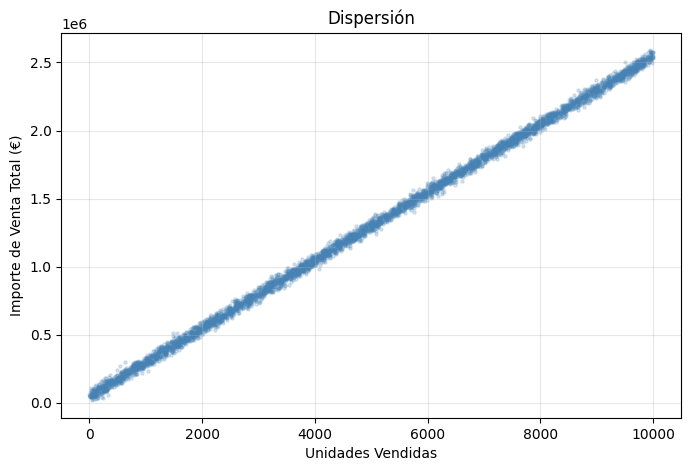

In [4]:
plt.figure(figsize=(8,5))
plt.scatter(df['Unidades'], df['Importe'], alpha=0.2, s=5, color='steelblue')
plt.xlabel('Unidades Vendidas')
plt.ylabel('Importe de Venta Total (€)')
plt.title('Dispersión')
plt.grid(True, alpha=0.3)
plt.show()

## 3. Características estadísticas principales

In [5]:
# Coeficiente de correlación de Pearson
r, p_valor = stats.pearsonr(df['Unidades'], df['Importe'])
print(f'Coeficiente de correlación (r): {r:.6f}')
print(f'P-valor:                        {p_valor:.2e}')

Coeficiente de correlación (r): 0.999397
P-valor:                        0.00e+00


## 4. Construir el modelo de Regresión Lineal

In [6]:
modelo = LinearRegression()
modelo.fit(df['Unidades'].values.reshape(-1,1), df['Importe'].values)

theta0 = modelo.intercept_
theta1 = modelo.coef_[0]

print(f'Theta 0 (intercepto / b): {theta0:,.4f}')
print(f'Theta 1 (pendiente  / m): {theta1:,.4f}')
print(f'Función hipótesis: h(x) = {theta1:.4f}·x + {theta0:,.4f}')

Theta 0 (intercepto / b): 50,966.1793
Theta 1 (pendiente  / m): 249.8450
Función hipótesis: h(x) = 249.8450·x + 50,966.1793


## 5. Visualización del modelo

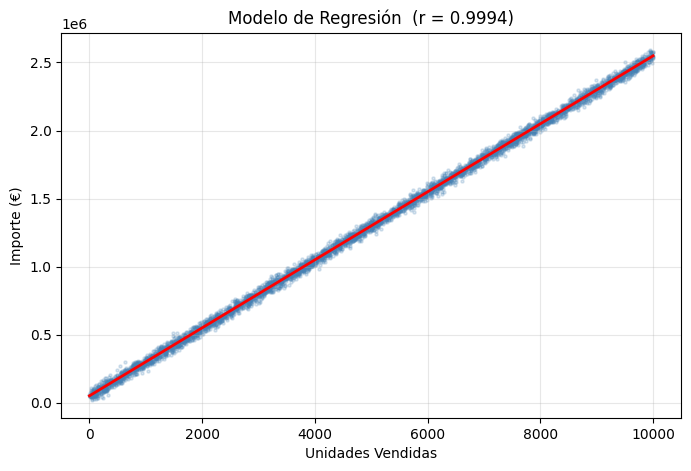

In [7]:
X_line = np.linspace(df['Unidades'].min(), df['Unidades'].max(), 300).reshape(-1,1)
y_line = modelo.predict(X_line)
plt.figure(figsize=(8,5))
plt.scatter(df['Unidades'], df['Importe'], alpha=0.2, s=5, color='steelblue', label='Datos')
plt.plot(X_line, y_line, 'r-', lw=2, label='Regresión lineal')
plt.xlabel('Unidades Vendidas')
plt.ylabel('Importe (€)')
plt.title(f'Modelo de Regresión  (r = {r:.4f})')
plt.grid(True, alpha=0.3)
plt.show()

## 6. Predicción

In [8]:
X_pred  = np.array([[5000]])
y_pred  = modelo.predict(X_pred)[0]
print(f'Para x = 5,000 unidades vendidas:')
print(f'  Importe estimado: €{y_pred:,.2f}')

Para x = 5,000 unidades vendidas:
  Importe estimado: €1,300,191.39


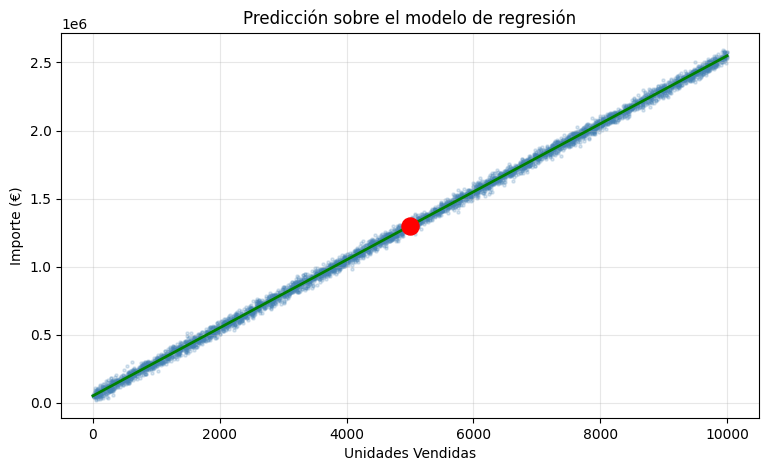

In [9]:
plt.figure(figsize=(9,5))
plt.scatter(df['Unidades'], df['Importe'], alpha=0.2, s=5, color='steelblue', label='Datos')
plt.plot(X_line, y_line, 'g-', lw=2, label='Regresión')
plt.scatter([5000], [y_pred], color='red', s=150, zorder=5,
            label=f'Pred. 5,000 uds → €{y_pred:,.0f}')
plt.xlabel('Unidades Vendidas')
plt.ylabel('Importe (€)')
plt.title('Predicción sobre el modelo de regresión')
plt.grid(True, alpha=0.3)
plt.show()

## 7. Resumen estadístico final

In [10]:
print('=' * 45)
print('  RESUMEN — MODELO DE REGRESIÓN LINEAL')
print('=' * 45)
print(f'  N (datos)              : 5,000')
print(f'  Coef. correlación (r)  : {r:.6f}')
print(f'  Theta 0 (intercepto)   : {theta0:>12,.2f} €')
print(f'  Theta 1 (pendiente)    : {theta1:>12,.4f}')
print(f'  h(x) = {theta1:.2f}·x + {theta0:,.2f}')
print(f'  Predicción (x=5,000)   : €{y_pred:>12,.2f}')
print('=' * 45)

  RESUMEN — MODELO DE REGRESIÓN LINEAL
  N (datos)              : 5,000
  Coef. correlación (r)  : 0.999397
  Theta 0 (intercepto)   :    50,966.18 €
  Theta 1 (pendiente)    :     249.8450
  h(x) = 249.85·x + 50,966.18
  Predicción (x=5,000)   : €1,300,191.39
